# 7. Modificación de la paleta de colores
## Librerias

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Imagen de referencia

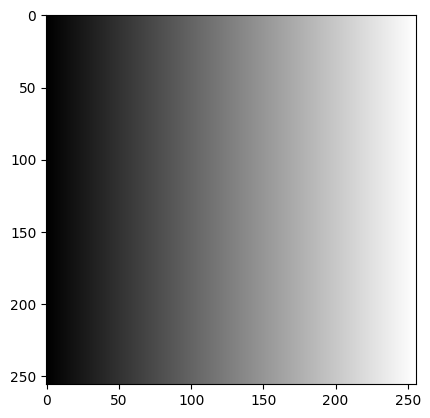

In [2]:
img = np.empty((256,256,3),dtype=np.uint8)


for i in range(256):
  img[:,i,:] = i

plt.imshow(img)
plt.show()

## Carga y visualización

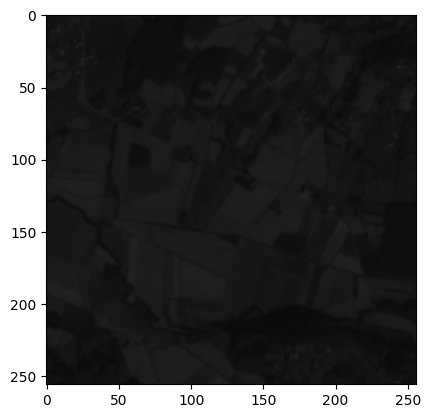

In [4]:
aquitain_img = cv2.imread('../img/AQUITAIN.png')

plt.imshow(aquitain_img)
plt.show()

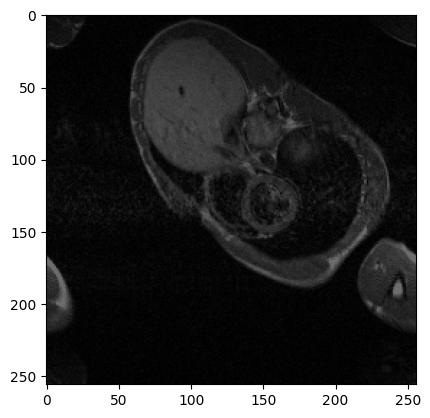

In [6]:
scanner_img = cv2.imread('../img/SCANNER.png')

plt.imshow(scanner_img)
plt.show()

## Aplicación de paleta de colores inversa

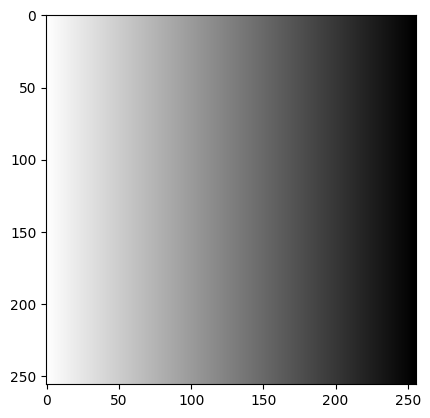

In [7]:
# aplicación a scanner
lut_inverse = np.zeros((256, 1), dtype=np.uint8)
for i in range(0,256):
    lut_inverse[i] = 255 - i


dstImage = cv2.LUT(img , lut_inverse )

plt.imshow(dstImage)
plt.show()

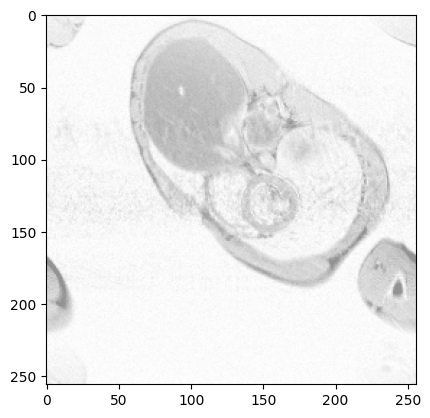

In [8]:
# aplicación a scanner
dstImage = cv2.LUT(scanner_img , lut_inverse )

plt.imshow(dstImage)
plt.show()

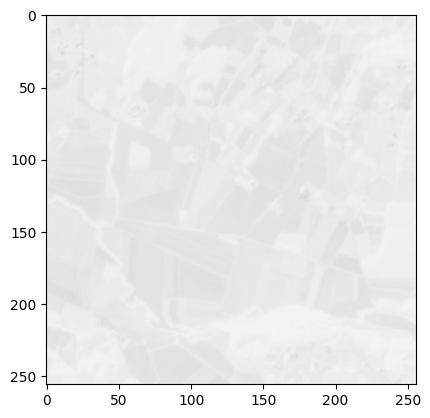

In [9]:
# aplicación a aquitain
dstImage = cv2.LUT(aquitain_img , lut_inverse )

plt.imshow(dstImage)
plt.show()

La paleta de colores es usada como mapeo de valores, en este caso escala de grises, a valores objectivo. Por ejemplo, este ejemplo, la paleta de colores inversa mapea la escala de gris (ej. 0) a su valor complemento (ej. 255). Por lo tanto aplicar esta paleta a una image da como resultado su version inversa, donde sus valores claros se mapean a valores oscuros y viceversa.

## Expansión lineal de contraste

In [10]:
def plot_imgs_side_by_side(img1, img2, title1='muscle, spot', title2='spot, muscle', plot=False):
  """ funcion para mostrar dos imagenes en la misma figura """
  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  axes[0].imshow(img1)
  axes[0].set_title(title1)
  axes[0].axis("off")

  if plot:
    axes[1].plot(img2)
  else:
    axes[1].imshow(img2)
  
  axes[1].set_title(title2)
  axes[1].axis("off")

  plt.tight_layout()
  plt.show()

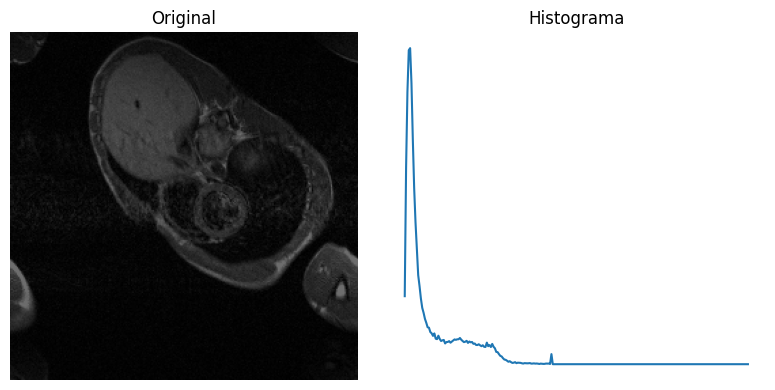

In [11]:
hist = cv2.calcHist([scanner_img],[0],None,[256],[0,256])

plot_imgs_side_by_side(scanner_img,hist,title1='Original',title2='Histograma',plot=True)

109 0


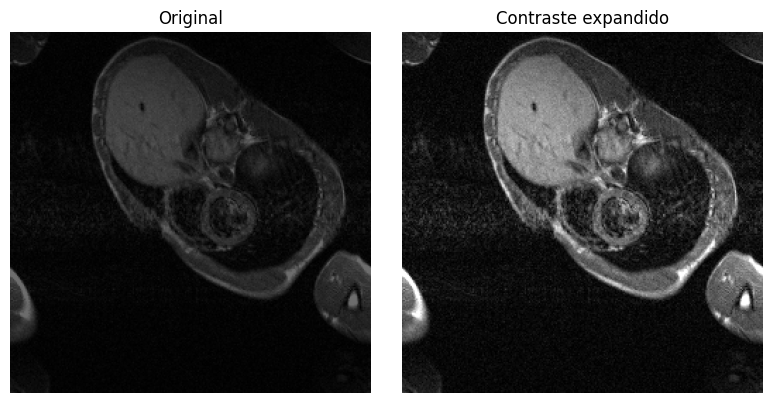

In [12]:
# expansion de contraste
I_min = np.min(scanner_img)
I_max = np.max(scanner_img)

print(I_max, I_min)

# Expansión lineal
stretch_img = ((scanner_img - I_min) / (I_max - I_min) * 255).astype(np.uint8)

plot_imgs_side_by_side(scanner_img, stretch_img, title1='Original', title2='Contraste expandido')

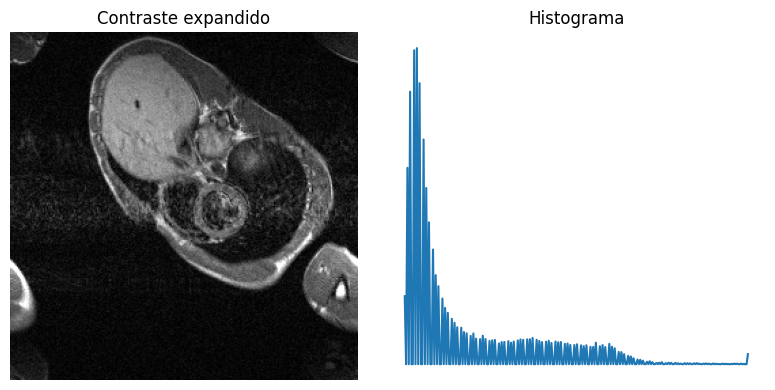

In [13]:
# histograma
hist = cv2.calcHist([stretch_img],[0],None,[256],[0,256])


plot_imgs_side_by_side(stretch_img, hist, title1='Contraste expandido',title2='Histograma',plot=True)

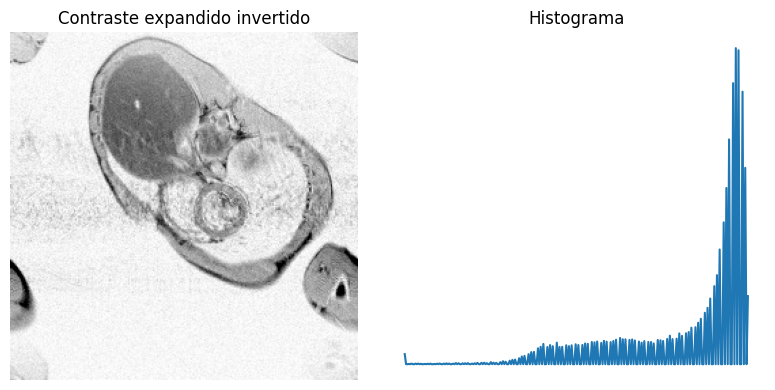

In [14]:
dstImage = cv2.LUT(stretch_img , lut_inverse )
hist = cv2.calcHist([dstImage],[0],None,[256],[0,256])

plot_imgs_side_by_side(dstImage, hist, title1='Contraste expandido invertido',title2='Histograma', plot=True)

## Comparativa

Comparando la imagen original con su version expandida es claro que la imagen expandida presenta detalles que eran oscuros en la original lo que puede ser el resultado de expandir su reducido espectro de grises hasta ocupar todo el range de valores posibles tal como se observa en los histogramas.

Por otro lado, la image expandida inversa presenta su version mas clara puesto que sus valores oscuros (los cuales eran predominantes) ahora se tranformaron en valores claro, esto permite observar con mas detalle su contenido. El efecto de esta transformación sobre el histograma es que, ahora el histograma es el reflejo del histograma expandido lo que significa que ahora los valores claros están mas presentes que los oscuros.